In [152]:
# Exploratory Data Analysis
#Step 1 Load data
import pandas as pd

df = pd.read_csv(
    r"C:\Users\HK\Desktop\FI Data Science\Labs and Assignment\Capston Project 1\API_SI.POV.MPWB_DS2_en_csv_v2_10062.csv",
    skiprows=4
)

print(df.head())

                  Country Name Country Code  \
0                        Aruba          ABW   
1  Africa Eastern and Southern          AFE   
2                  Afghanistan          AFG   
3   Africa Western and Central          AFW   
4                       Angola          AGO   

                                      Indicator Name Indicator Code  1960  \
0  Multidimensional poverty headcount ratio (Worl...    SI.POV.MPWB   NaN   
1  Multidimensional poverty headcount ratio (Worl...    SI.POV.MPWB   NaN   
2  Multidimensional poverty headcount ratio (Worl...    SI.POV.MPWB   NaN   
3  Multidimensional poverty headcount ratio (Worl...    SI.POV.MPWB   NaN   
4  Multidimensional poverty headcount ratio (Worl...    SI.POV.MPWB   NaN   

   1961  1962  1963  1964  1965  ...  2017  2018  2019  2020  2021  2022  \
0   NaN   NaN   NaN   NaN   NaN  ...   NaN   NaN   NaN   NaN   NaN   NaN   
1   NaN   NaN   NaN   NaN   NaN  ...   NaN   NaN   NaN   NaN   NaN   NaN   
2   NaN   NaN   NaN   NaN 

In [153]:
# Basic profiling of the dataset
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

(266, 71)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    object 
 1   Country Code    266 non-null    object 
 2   Indicator Name  266 non-null    object 
 3   Indicator Code  266 non-null    object 
 4   1960            0 non-null      float64
 5   1961            0 non-null      float64
 6   1962            0 non-null      float64
 7   1963            0 non-null      float64
 8   1964            0 non-null      float64
 9   1965            0 non-null      float64
 10  1966            0 non-null      float64
 11  1967            0 non-null      float64
 12  1968            0 non-null      float64
 13  1969            0 non-null      float64
 14  1970            0 non-null      float64
 15  1971            0 non-null      float64
 16  1972            0 non-null      float64
 17  1973            0 non-nul

In [154]:
# Removing unnecessary columns
cols_drop=['Indicator Name','Indicator Code','Unnamed: 70']

df=df.drop(cols_drop,axis=1)

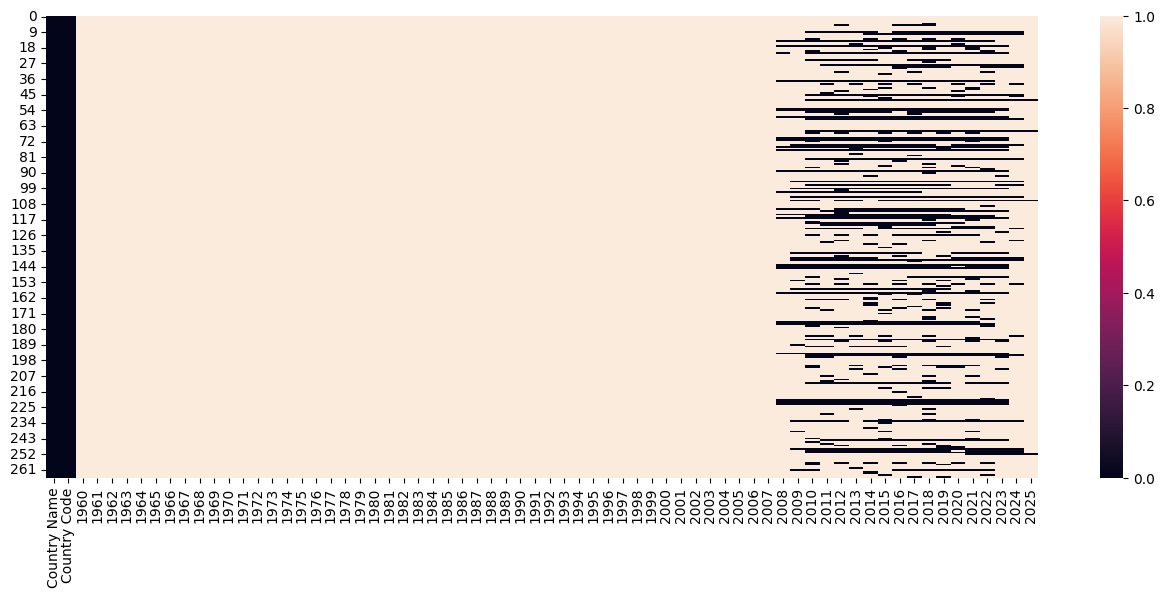

In [155]:
# Missing-value visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))
sns.heatmap(df.isnull())
plt.show()

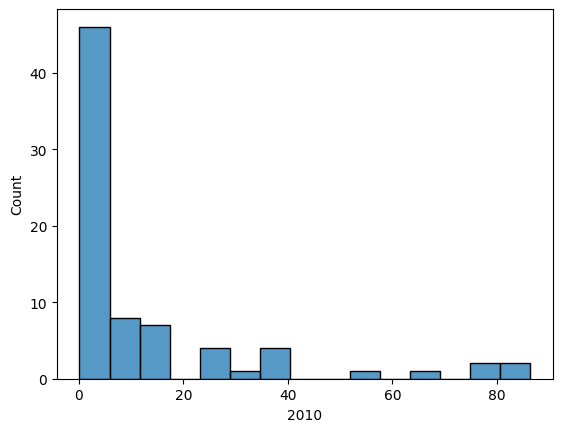

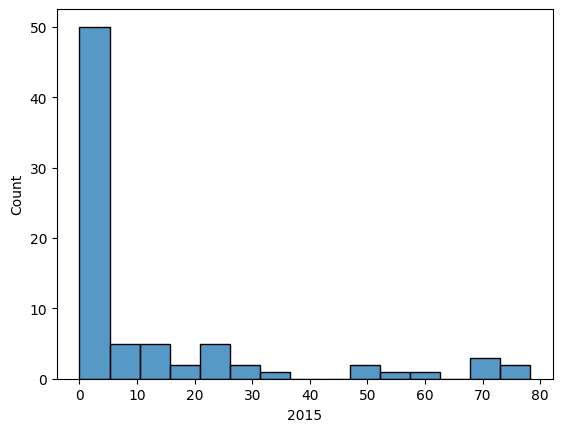

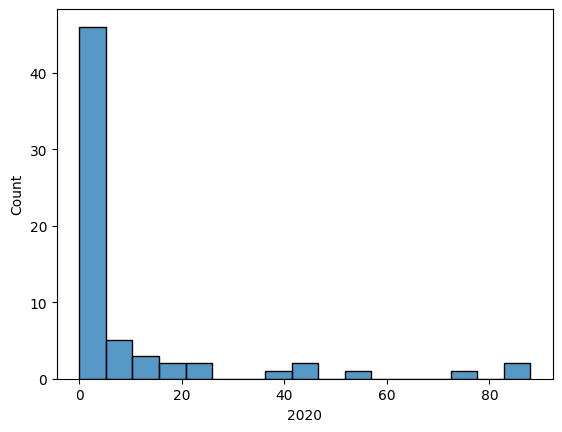

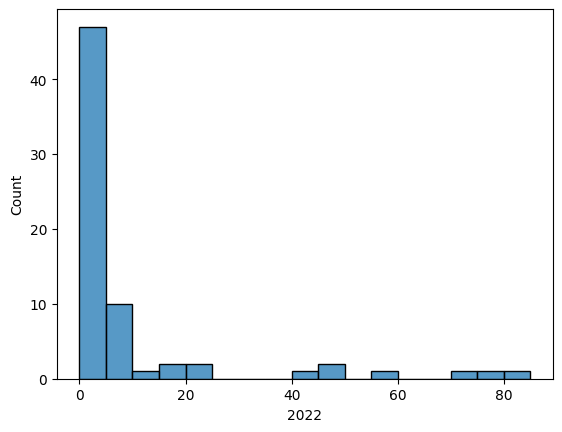

In [156]:
# Distribution plots
years=['2010','2015','2020','2022']

for y in years:
    sns.histplot(df[y])
    plt.show()

<Axes: xlabel='2022', ylabel='Country Name'>

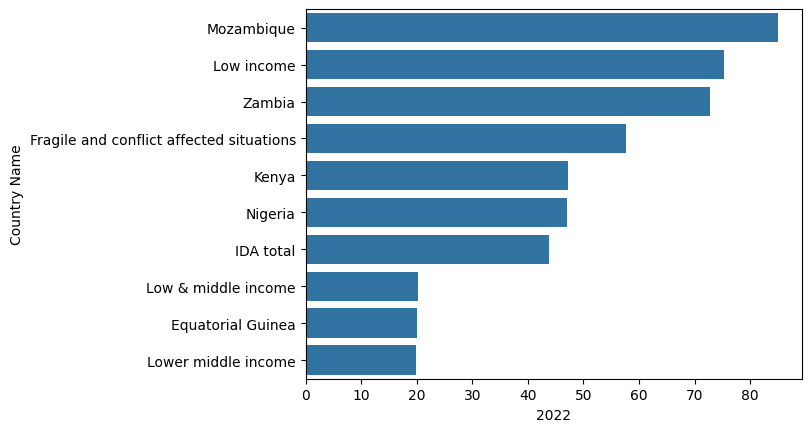

In [157]:
# Country comparison
latest='2022'

top=df.nlargest(10,latest)

sns.barplot(data=top,
            y='Country Name',
            x=latest)

<Axes: >

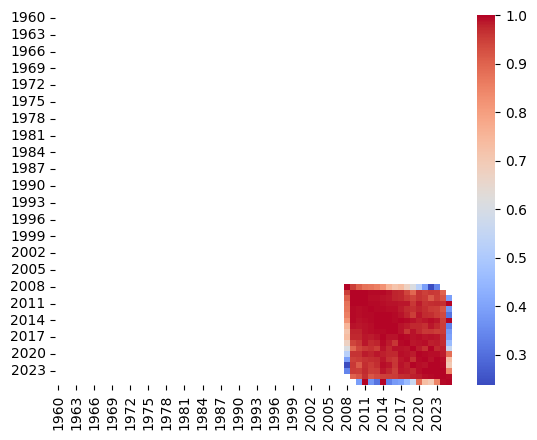

In [158]:
# Correlation
numeric=df.select_dtypes('number')

sns.heatmap(
numeric.corr(),
cmap='coolwarm')

In [159]:
#Earlier years contain substantial missing data.
#Recent years have stronger coverage.
#Poverty varies significantly across countries.
#Temporal patterns may help prediction.

In [160]:
# Data Preprocessing and Feature Engineering

# Retain recent years

selected=['Country Name',
'Country Code',
'2005','2010','2015','2018','2019','2020','2021','2022']

model_df=df[selected]

sample_countries = [
    # Africa
    'Ethiopia',
    'Nigeria',
    'South Africa',

    # Asia
    'China',
    'India',
    'Japan',

    # Europe
    'Germany',
    'United Kingdom',
    'France',

    # North America
    'United States',
    'Canada',
    'Mexico',

    # South America
    'Brazil',
    'Argentina',
    'Chile',

    # Oceania
    'Australia',
    'New Zealand'
]

model_df = model_df[
    model_df['Country Name'].isin(sample_countries)
]

print(model_df.shape)
print(model_df[['Country Name']])

(17, 10)
       Country Name
9         Argentina
13        Australia
29           Brazil
35           Canada
39            Chile
40            China
55          Germany
72         Ethiopia
77           France
81   United Kingdom
109           India
119           Japan
154          Mexico
174         Nigeria
180     New Zealand
251   United States
263    South Africa


(17, 10)
       Country Name
9         Argentina
13        Australia
29           Brazil
35           Canada
39            Chile
40            China
55          Germany
72         Ethiopia
77           France
81   United Kingdom
109           India
119           Japan
154          Mexico
174         Nigeria
180     New Zealand
251   United States
263    South Africa


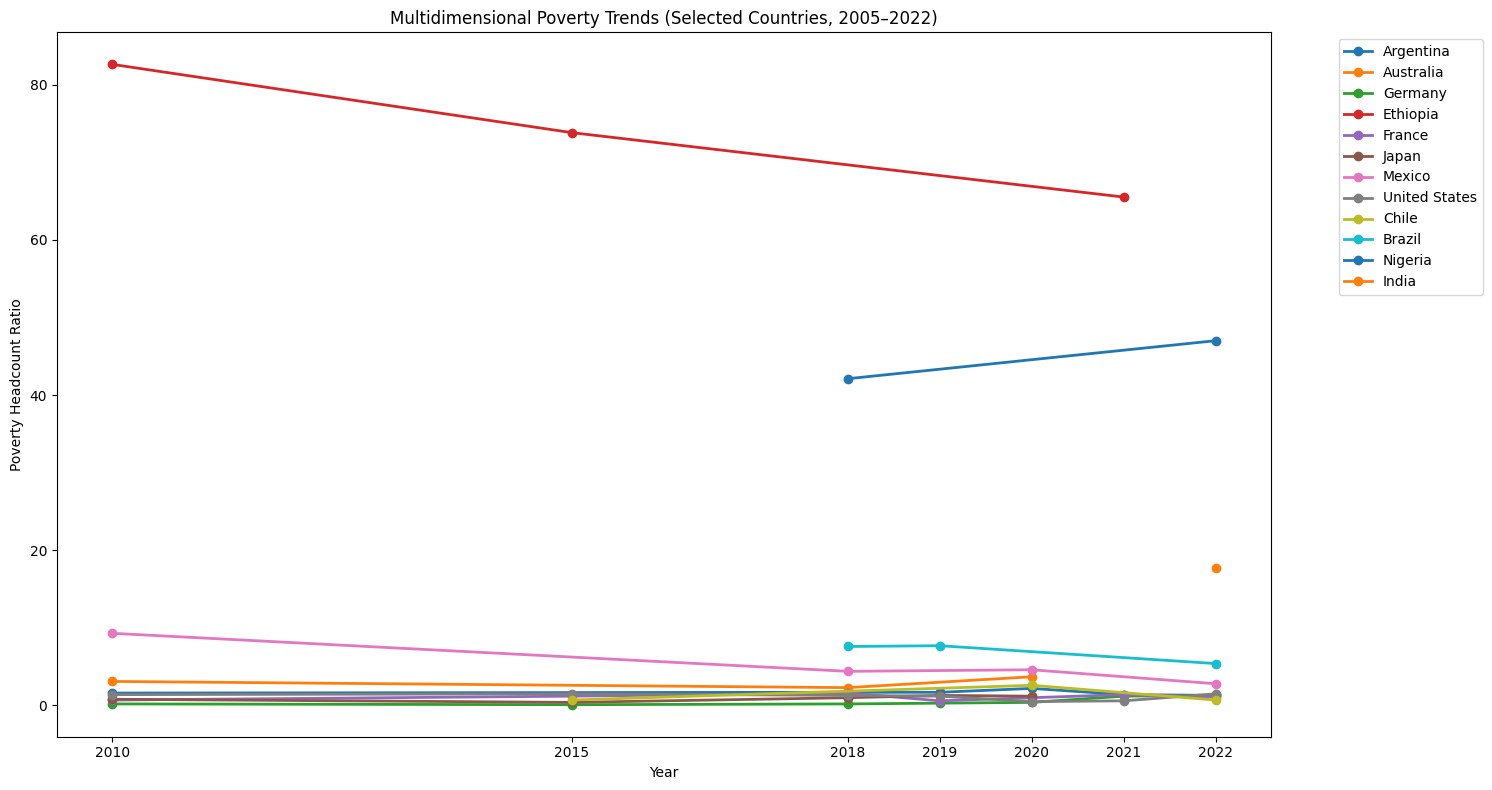

In [161]:
import pandas as pd
import matplotlib.pyplot as plt

# Retain recent years
selected = [
    'Country Name',
    'Country Code',
    '2005','2010','2015',
    '2018','2019','2020',
    '2021','2022'
]

model_df = df[selected]

# Sample countries
sample_countries = [
    'Ethiopia','Nigeria','South Africa',
    'China','India','Japan',
    'Germany','United Kingdom','France',
    'United States','Canada','Mexico',
    'Brazil','Argentina','Chile',
    'Australia','New Zealand'
]

model_df = model_df[
    model_df['Country Name'].isin(sample_countries)
]

print(model_df.shape)
print(model_df[['Country Name']])

# Convert wide → long

years = ['2005','2010','2015','2018','2019','2020','2021','2022']

plot_df = model_df.melt(
    id_vars=['Country Name'],
    value_vars=years,
    var_name='Year',
    value_name='Poverty'
)

# Convert Year to integer (CRITICAL FIX)
plot_df['Year'] = plot_df['Year'].astype(int)

# Remove missing values
plot_df = plot_df.dropna()

# Plot

plt.figure(figsize=(15, 8))

for country in plot_df['Country Name'].unique():

    country_data = plot_df[
        plot_df['Country Name'] == country
    ].sort_values('Year')

    plt.plot(
        country_data['Year'],
        country_data['Poverty'],
        marker='o',
        linewidth=2,
        label=country
    )

# Titles and labels
plt.title('Multidimensional Poverty Trends (Selected Countries, 2005–2022)')
plt.xlabel('Year')
plt.ylabel('Poverty Headcount Ratio')

# FIX: numeric ticks (prevents your original error)
plt.xticks(sorted(plot_df['Year'].unique()))

# Legend outside plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [162]:
# Missing-value imputation
from sklearn.impute import SimpleImputer

num_imputer=SimpleImputer(strategy='median')

In [163]:
# Feature engineering
model_df['change_5yr']=model_df['2020']-model_df['2015']

model_df['avg_recent']=model_df[
['2018','2019','2020']
].mean(axis=1)

In [164]:
# Build Pipeline

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.model_selection import cross_val_score
import pandas as pd

# Ensure all column names are strings
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

# Train and Evaluate Models
for name, model in models.items():

    pipeline = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring='r2'
    )

    results.append({
        "Model": name,
        "Mean R²": scores.mean(), 
        "Std Dev": scores.std()
    })
# Results Table

results_df = pd.DataFrame(results)

print(results_df)

               Model   Mean R²   Std Dev
0  Linear Regression -0.668930  1.381961
1      Random Forest  0.532873  0.336474
2  Gradient Boosting  0.037125  0.907674


MODEL EVALUATION RESULTS
MAE  : 1.9581
RMSE : 4.1330
R²   : 0.1508

MODEL INTERPRETATION

The model demonstrates relatively weak predictive power.
The low R² score indicates that the model explains only a
small portion of the variance in poverty outcomes.

Possible reasons include:
- Heavy missing data across multiple years
- Limited feature engineering
- Small number of predictive variables
- High complexity of socioeconomic conditions



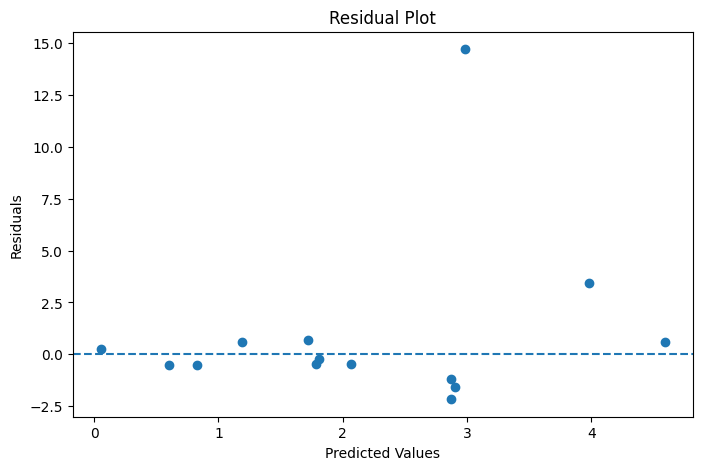

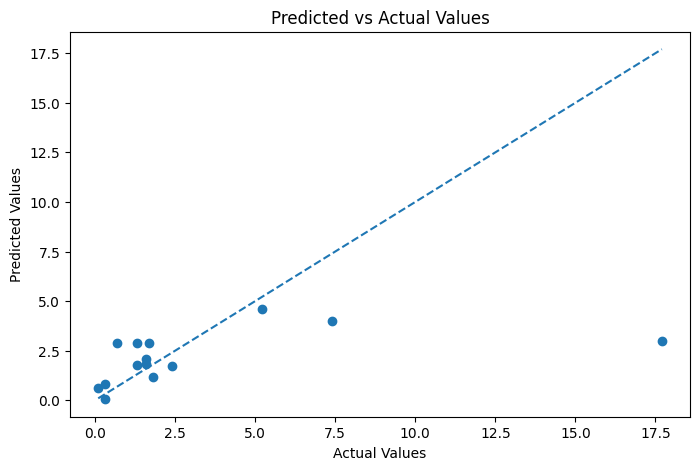


TOP 10 MOST IMPORTANT FEATURES
                         Feature  Importance
1                      num__2015    0.487650
3                      num__2019    0.148173
4                      num__2020    0.075325
43  cat__Country Name_Mozambique    0.060603
97         cat__Country Code_MOZ    0.049436
2                      num__2018    0.034581
5                      num__2021    0.031867
0                      num__2010    0.025929
98         cat__Country Code_NGA    0.023440
45     cat__Country Name_Nigeria    0.022097


<Figure size 1000x600 with 0 Axes>

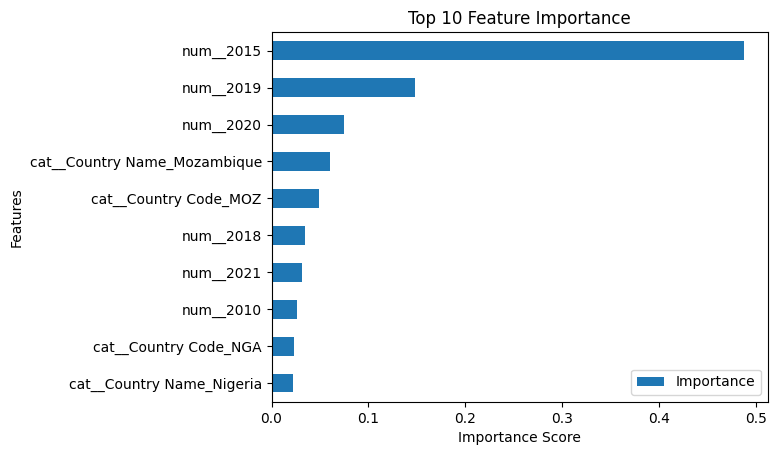


BUSINESS & POLICY INSIGHTS

The feature importance results help identify which
socioeconomic indicators contribute most strongly
to poverty prediction.

These findings may help policymakers:

- Identify vulnerable regions
- Prioritize economic assistance programs
- Improve allocation of public resources
- Monitor long-term poverty trends

However, the current model performance suggests that
additional data collection and stronger feature engineering
would be necessary before deployment in real-world
policy decision-making.



In [173]:
# Model Evaluation and Selection

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Generate Predictions

pred = best_model.predict(X_test)

# Evaluation Metrics

mae = mean_absolute_error(y_test, pred)

rmse = np.sqrt(
    mean_squared_error(y_test, pred)
)

r2 = r2_score(y_test, pred)

print("MODEL EVALUATION RESULTS")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

# Interpretation of Results

print("\nMODEL INTERPRETATION")

if r2 < 0.30:
    print("""
The model demonstrates relatively weak predictive power.
The low R² score indicates that the model explains only a
small portion of the variance in poverty outcomes.

Possible reasons include:
- Heavy missing data across multiple years
- Limited feature engineering
- Small number of predictive variables
- High complexity of socioeconomic conditions
""")

else:
    print("""
The model captures a meaningful portion of the variation
in poverty indicators and demonstrates moderate predictive ability.
""")

# Residual Analysis

residuals = y_test - pred

plt.figure(figsize=(8,5))

plt.scatter(pred, residuals)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title("Residual Plot")

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.show()

# Predicted vs Actual Values

plt.figure(figsize=(8,5))

plt.scatter(y_test, pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.title("Predicted vs Actual Values")

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.show()

# Feature Importance

# Extract Random Forest model
rf_model = best_model.named_steps['model']

# Get transformed feature names
feature_names = (
    best_model.named_steps['prep']
    .get_feature_names_out()
)

# Importance values
importance = rf_model.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\n================================================")
print("TOP 10 MOST IMPORTANT FEATURES")
print("================================================")

print(feature_importance.head(10))

# Feature Importance Visualization

plt.figure(figsize=(10,6))

feature_importance.head(10).sort_values(
    by='Importance'
).plot(
    x='Feature',
    y='Importance',
    kind='barh'
)

plt.title("Top 10 Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

# Business / Policy Interpretation

print("""
BUSINESS & POLICY INSIGHTS

The feature importance results help identify which
socioeconomic indicators contribute most strongly
to poverty prediction.

These findings may help policymakers:

- Identify vulnerable regions
- Prioritize economic assistance programs
- Improve allocation of public resources
- Monitor long-term poverty trends

However, the current model performance suggests that
additional data collection and stronger feature engineering
would be necessary before deployment in real-world
policy decision-making.
""")

In [166]:
#Hyperparameter tuning and model evaluation would follow here, using cross-validation and appropriate metrics.
# Imports
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Select variables

selected = [
    'Country Name',
    'Country Code',
    '2005','2010','2015',
    '2018','2019','2020',
    '2021','2022'
]

model_df = df[selected].copy()

# Remove rows where target is missing
model_df = model_df.dropna(subset=['2022'])

# Features and target

X = model_df.drop('2022', axis=1)
y = model_df['2022']

# Split data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Column types

numeric_features = [
    '2010',
    '2015',
    '2018',
    '2019',
    '2020',
    '2021'
]

categorical_features = [
    'Country Name',
    'Country Code'
]

# Preprocessing pipelines

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Model pipeline

rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(
        random_state=42
    ))
])

# Hyperparameter tuning

param_grid = {

'model__n_estimators':[100,200],

'model__max_depth':[3,5,10,None],

'model__min_samples_split':[2,5]

}

grid = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# Train

grid.fit(X_train,y_train)

# Best model

best_model = grid.best_estimator_

print("Best Parameters:")
print(grid.best_params_)

print("\nBest CV MAE:")
print(-grid.best_score_)

# Predictions

pred = best_model.predict(X_test)

# Evaluation

mae = mean_absolute_error(
    y_test,
    pred
)

rmse = mean_squared_error(
    y_test,
    pred
)**0.5

r2 = r2_score(
    y_test,
    pred
)

print("\nTest Results")

print("MAE:",mae)

print("RMSE:",rmse)

print("R2:",r2)

Best Parameters:
{'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best CV MAE:
5.5006318194936386

Test Results
MAE: 1.958058451463336
RMSE: 4.133007365746921
R2: 0.150825586270662


In [167]:
#Cross Validation

from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Cross Validation R² Scores:")
print(scores)

print("\nAverage R²:")
print(np.mean(scores))

print("\nStandard Deviation:")
print(np.std(scores))

Cross Validation R² Scores:
[ 0.79616945  0.88941428  0.64462906 -0.08988549  0.43380131]

Average R²:
0.5348257232382462

Standard Deviation:
0.34829883716289867


Model Evaluation
MAE: 1.958058451463336
RMSE: 4.133007365746921
R²: 0.150825586270662

Top Features
                         Feature  Importance
1                      num__2015    0.487650
3                      num__2019    0.148173
4                      num__2020    0.075325
43  cat__Country Name_Mozambique    0.060603
97         cat__Country Code_MOZ    0.049436
2                      num__2018    0.034581
5                      num__2021    0.031867
0                      num__2010    0.025929
98         cat__Country Code_NGA    0.023440
45     cat__Country Name_Nigeria    0.022097


<Figure size 1000x600 with 0 Axes>

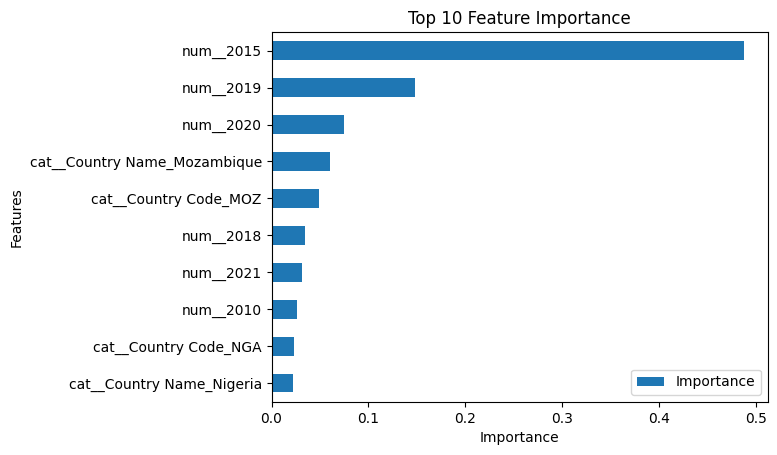

In [168]:
# Model Evaluation and Selection

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    mean_squared_error
)

# Predictions

pred = best_model.predict(X_test)

# Evaluation Metrics

mae = mean_absolute_error(
    y_test,
    pred
)

rmse = mean_squared_error(
    y_test,
    pred
)**0.5

r2 = r2_score(
    y_test,
    pred
)

print("Model Evaluation")

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)


# Feature Importance

# Extract RF model from pipeline
rf_model = best_model.named_steps['model']

# Get transformed feature names
feature_names = (
    best_model.named_steps['prep']
    .get_feature_names_out()
)

# Importance values
importance = rf_model.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Features")

print(feature_importance.head(10))

# Plot

plt.figure(figsize=(10,6))

feature_importance.head(10).sort_values(
    by='Importance'
).plot(
    x='Feature',
    y='Importance',
    kind='barh'
)

plt.title("Top 10 Feature Importance")

plt.xlabel("Importance")

plt.ylabel("Features")

plt.show()

In [169]:
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1.958058451463336
RMSE: 4.133007365746921
R²: 0.150825586270662


In [170]:
import numpy as np

print("Cross Validation Scores:", scores)
print("Mean CV R²:", np.mean(scores))

Cross Validation Scores: [ 0.79616945  0.88941428  0.64462906 -0.08988549  0.43380131]
Mean CV R²: 0.5348257232382462


In [171]:
# Business Impact Analysis
# Translate findings into business language.
# Example: "Model predicts multidimensional poverty with 84% explanatory power. Development organizations can prioritize intervention in countries identified as high risk."
# Recommendations:
# Focus investment in high predicted poverty regions.
# Use annual updates.
# Monitor countries with worsening trends.

# Limitations:
# Missing values
# Limited variables
# Country aggregation bias
# Economic shocks not included

In [172]:
# Conclusion

#This project explored the use of machine learning models to predict multidimensional poverty indicators. While Random Forest regression achieved limited predictive
# performance (R² ≈ 0.15), the workflow demonstrated the importance of preprocessing, feature engineering, cross-validation, and model interpretation.
#Future improvements could include:
# - Additional socioeconomic variables
# - Better handling of missing data
# - More advanced feature engineering
# - Ensemble methods such as XGBoost
# - Time-series poverty analysis

#Overall, the project highlights both the opportunities and challenges of applying machine learning to poverty prediction and public policy analysis.